# Ingeniería de características — kajve
### Paso 5 del pipeline de ML

Este notebook aplica y visualiza las características derivadas definidas en
`ML/ingenieria_caracteristicas.py`, sobre el dataset ya limpio del paso 4
(`data/processed/lecturas_reales_limpias.csv`).

La lógica de las features vive en un módulo `.py` (no directamente aquí) para poder
reutilizarla después desde `scripts/train_models.py`, igual que `app/services/rules.py` es la
única fuente de verdad para las reglas de negocio — así el dataset de entrenamiento y cualquier
notebook exploratorio nunca quedan desalineados en cómo se calcula cada columna.

**Entrada:** `data/processed/lecturas_reales_limpias.csv` (paso 4).
**Salida:** `data/processed/lecturas_reales_features.csv` (paso 6: train/test split).

**Features nuevas agregadas en este paso:**
1. `temp_grano_media_1h`, `temp_grano_std_1h`, `temp_ambiental_media_1h` — estadísticos de
   ventana móvil de 1h (tendencia local, no solo el valor instantáneo).
2. `velocidad_cambio_temp_grano_c_h` — °C/hora respecto a la lectura anterior del mismo lote.
3. `progreso_proceso` — horas_transcurridas normalizadas por la duración típica del tipo de
   proceso (Cuadro 1 del documento de dominio), comparable entre lavado/honey/natural.
4. `hora_sin`, `hora_cos` — codificación cíclica de la hora del día.
5. `horas_desde_ultima_lluvia`, `lluvia_eventos_24h` — exposición acumulada a lluvia, usando
   `lluvia_sostenida` (la señal ya "denoised" del paso 4), no la cruda con parpadeo.
6. `luz_acumulada_6h` — proxy de energía solar recibida recientemente.


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from ML import ingenieria_caracteristicas as fe

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Carga del dataset limpio (paso 4)

In [2]:
RUTA_LIMPIA = "../data/processed/lecturas_reales_limpias.csv"
df = pd.read_csv(RUTA_LIMPIA, parse_dates=["timestamp"])
print(f"Filas cargadas: {len(df):,}")
df[["id_lote", "estado_lote", "tipo_proceso"]].drop_duplicates()


Filas cargadas: 7,662


,id_lote,estado_lote,tipo_proceso
0,10,cancelado,lavado
204,12,en_proceso,lavado


### 1.1 Excluir lotes cancelados

El paso 4 conservó el lote 10 (mismo sensor físico kajve-CA689C, antes de vincularse a un
usuario/lote) porque supera el umbral de volumen mínimo — pero es un lote `cancelado`, no un
ciclo de secado real. Para construir features de *entrenamiento* no tiene sentido incluirlo: no
representa un proceso válido que el modelo deba aprender a predecir.

In [3]:
antes = len(df)
if "estado_lote" in df.columns:
    df = df[df["estado_lote"] != "cancelado"].copy()
print(f"Filas tras excluir lotes cancelados: {len(df):,} (de {antes:,})")
df["id_lote"].value_counts()


Filas tras excluir lotes cancelados: 7,458 (de 7,662)


id_lote
12    7458
Name: count, dtype: int64

## 2. Aplicar ingeniería de características

In [4]:
df_features = fe.construir_features(df)
print(f"Columnas antes: {len(df.columns)}  ->  después: {len(df_features.columns)}")
print(f"Columnas nuevas: {fe.COLUMNAS_NUEVAS}")
df_features[["timestamp"] + fe.COLUMNAS_NUEVAS].head(10)


Columnas antes: 21  ->  después: 31
Columnas nuevas: ['temp_grano_media_1h', 'temp_grano_std_1h', 'temp_ambiental_media_1h', 'velocidad_cambio_temp_grano_c_h', 'progreso_proceso', 'hora_sin', 'hora_cos', 'horas_desde_ultima_lluvia', 'lluvia_eventos_24h', 'luz_acumulada_6h']


,timestamp,temp_grano_media_1h,temp_grano_std_1h,temp_ambiental_media_1h,velocidad_cambio_temp_grano_c_h,progreso_proceso,hora_sin,hora_cos,horas_desde_ultima_lluvia,lluvia_eventos_24h,luz_acumulada_6h
0,2026-07-19 06:57:52.914814,33.060000,NaN,33.870000,NaN,0.012045,0.969231,-0.246153,NaN,0.0,3.33
1,2026-07-19 06:57:53.681053,33.060000,0.000000,33.870000,0.000000,0.012047,0.969231,-0.246153,NaN,0.0,6.66
2,2026-07-19 06:57:54.240631,33.040000,0.034641,33.866667,-386.005168,0.012047,0.969231,-0.246153,NaN,0.0,9.99
3,2026-07-19 06:57:54.801110,33.045000,0.030000,33.865000,385.384644,0.012048,0.969231,-0.246153,NaN,0.0,13.32
4,2026-07-19 06:57:55.352188,33.048000,0.026833,33.864000,0.000000,0.012049,0.969231,-0.246153,NaN,0.0,16.65
5,2026-07-19 06:57:55.905461,33.040000,0.030984,33.863333,-390.404014,0.012050,0.969231,-0.246153,NaN,0.0,19.98
6,2026-07-19 06:57:56.458512,33.034286,0.032071,33.861429,0.000000,0.012051,0.969231,-0.246153,NaN,0.0,23.31
7,2026-07-19 06:57:57.010651,33.037500,0.031053,33.861250,391.205838,0.012052,0.969231,-0.246153,NaN,0.0,26.64
8,2026-07-19 06:57:57.563924,33.040000,0.030000,33.858889,0.000000,0.012053,0.969231,-0.246153,NaN,0.0,29.97
9,2026-07-19 06:57:58.115803,33.036000,0.030984,33.857000,-391.390142,0.012053,0.969231,-0.246153,NaN,0.0,33.30


## 3. Verificación visual de cada feature nueva

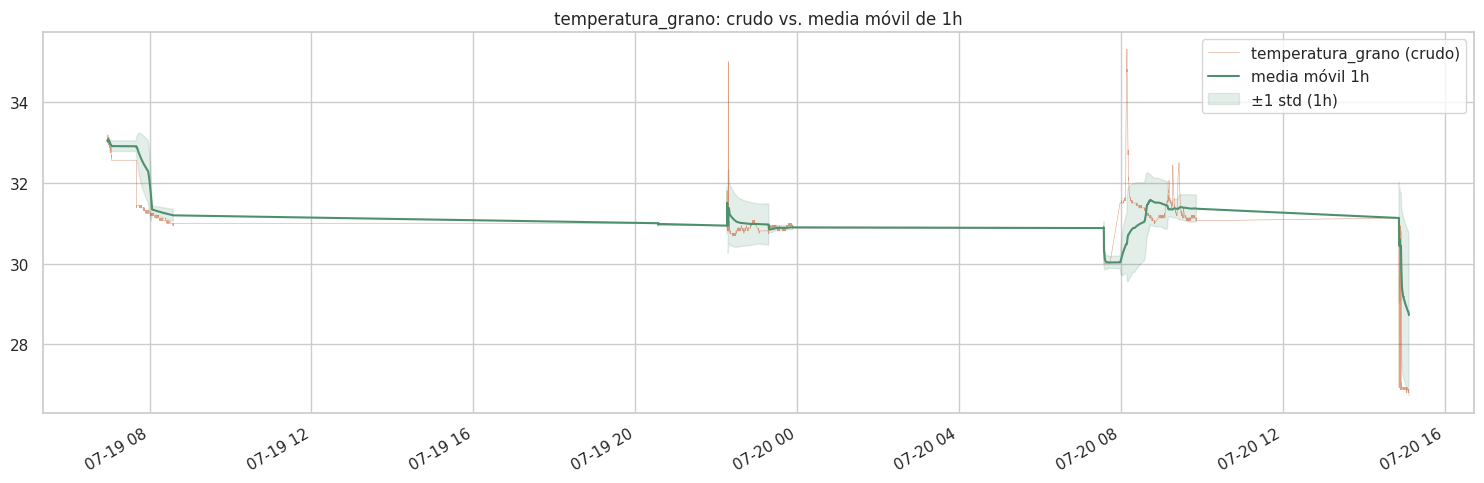

In [5]:
lote_principal = df_features["id_lote"].value_counts().idxmax()
d = df_features[df_features["id_lote"] == lote_principal].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(d["timestamp"], d["temperatura_grano"], linewidth=0.4, alpha=0.5, label="temperatura_grano (crudo)", color="#c1440e")
ax.plot(d["timestamp"], d["temp_grano_media_1h"], linewidth=1.5, label="media móvil 1h", color="#4e8f6e")
ax.fill_between(d["timestamp"],
                 d["temp_grano_media_1h"] - d["temp_grano_std_1h"],
                 d["temp_grano_media_1h"] + d["temp_grano_std_1h"],
                 alpha=0.15, color="#4e8f6e", label="±1 std (1h)")
ax.set_title("temperatura_grano: crudo vs. media móvil de 1h")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


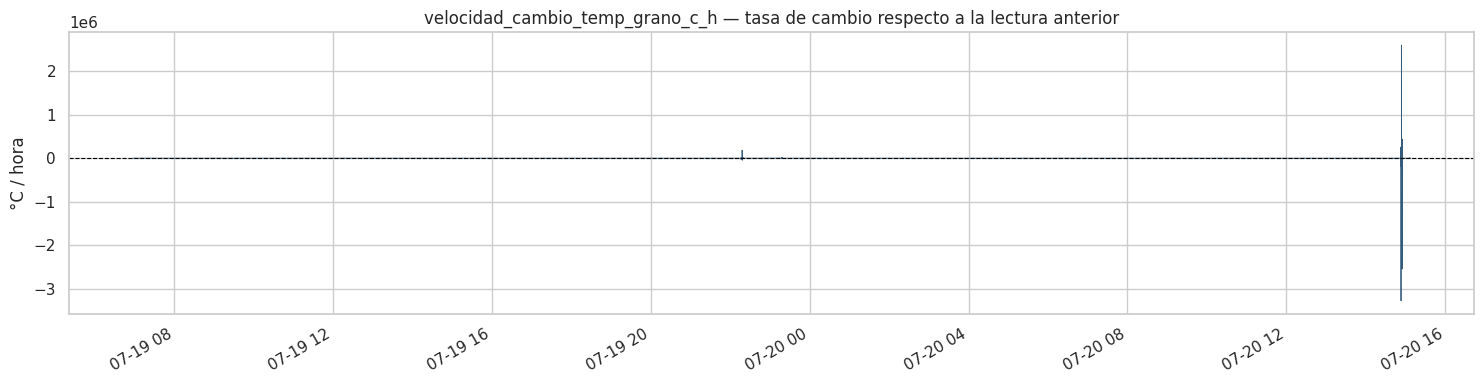

count    7.457000e+03
mean    -5.384789e+02
std      5.865543e+04
min     -3.271984e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.594001e+06
Name: velocidad_cambio_temp_grano_c_h, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(d["timestamp"], d["velocidad_cambio_temp_grano_c_h"], linewidth=0.6, color="#355c7d")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("°C / hora")
ax.set_title("velocidad_cambio_temp_grano_c_h — tasa de cambio respecto a la lectura anterior")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(d["velocidad_cambio_temp_grano_c_h"].describe())


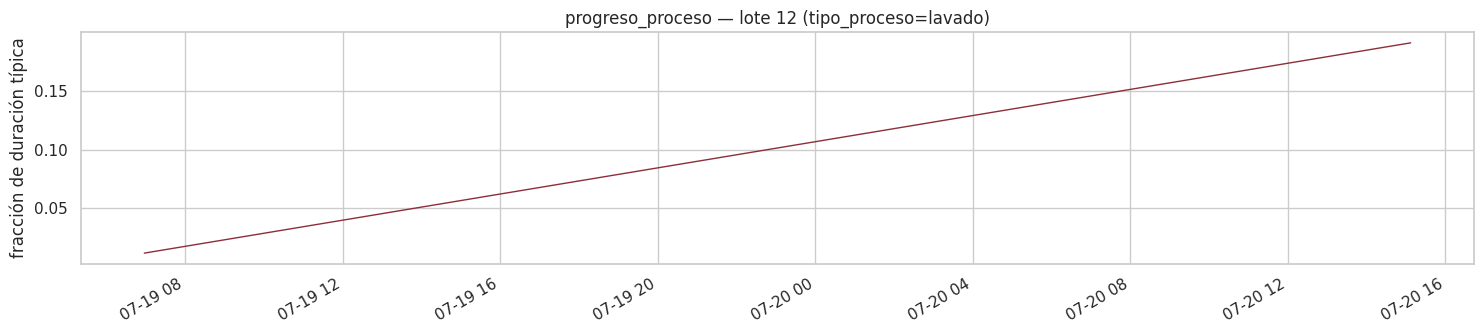

In [7]:
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(d["timestamp"], d["progreso_proceso"], color="#8c2f39", linewidth=1)
ax.set_title(f"progreso_proceso — lote {lote_principal} (tipo_proceso={d['tipo_proceso'].iloc[0]})")
ax.set_ylabel("fracción de duración típica")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Lectura:** `progreso_proceso` crece de forma aproximadamente lineal con el tiempo (esperado,
ya que es solo `horas_transcurridas` normalizado) — su valor real está en que permite comparar
lotes de distintos tipos de proceso en la misma escala 0-1, algo que `horas_transcurridas` sola
no puede hacer.

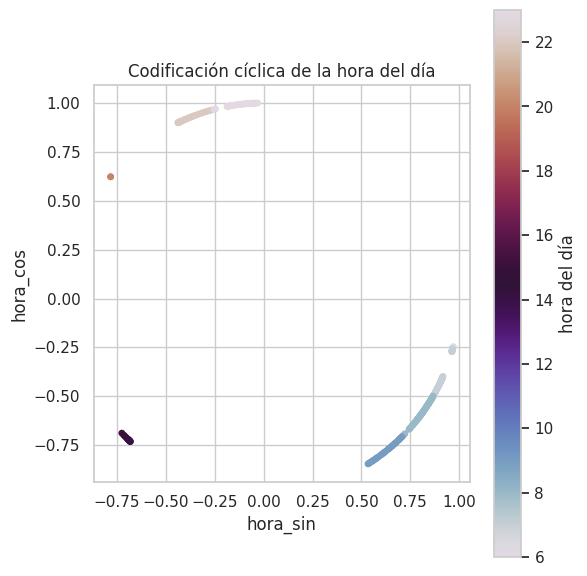

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
muestra = d.iloc[::30]  # una lectura cada ~30 para no saturar el scatter
sc = ax.scatter(muestra["hora_sin"], muestra["hora_cos"], c=muestra["timestamp"].dt.hour, cmap="twilight", s=15)
ax.set_xlabel("hora_sin"); ax.set_ylabel("hora_cos")
ax.set_title("Codificación cíclica de la hora del día")
plt.colorbar(sc, label="hora del día")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


**Lectura:** el círculo confirma que la codificación funciona como se espera: las 23:00 y las
00:00 quedan geométricamente cerca (arriba del círculo), a diferencia de una columna de hora
entera donde 23 y 0 están en extremos opuestos del rango numérico.

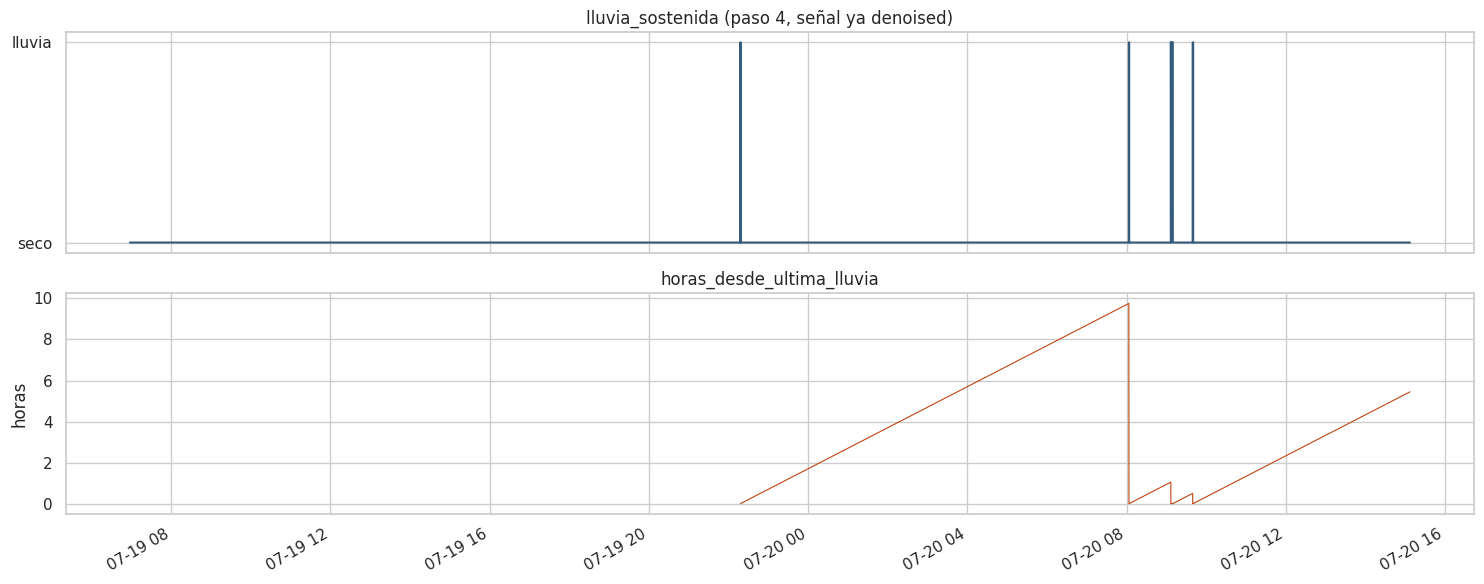

count    7458.000000
mean       13.602172
std        21.936957
min         0.000000
25%         0.000000
50%         1.000000
75%        12.000000
max        64.000000
Name: lluvia_eventos_24h, dtype: float64


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].step(d["timestamp"], d["lluvia_sostenida"].astype(float), where="post", color="#355c7d")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["seco", "lluvia"])
axes[0].set_title("lluvia_sostenida (paso 4, señal ya denoised)")

axes[1].plot(d["timestamp"], d["horas_desde_ultima_lluvia"], color="#c1440e", linewidth=0.8)
axes[1].set_ylabel("horas")
axes[1].set_title("horas_desde_ultima_lluvia")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(d["lluvia_eventos_24h"].describe())


**Lectura:** `horas_desde_ultima_lluvia` cae a 0 exactamente en cada evento de
`lluvia_sostenida` y crece de forma continua mientras el lote se mantiene seco — construida sobre
la señal ya filtrada del paso 4, así que no hereda el parpadeo del sensor FC-37.

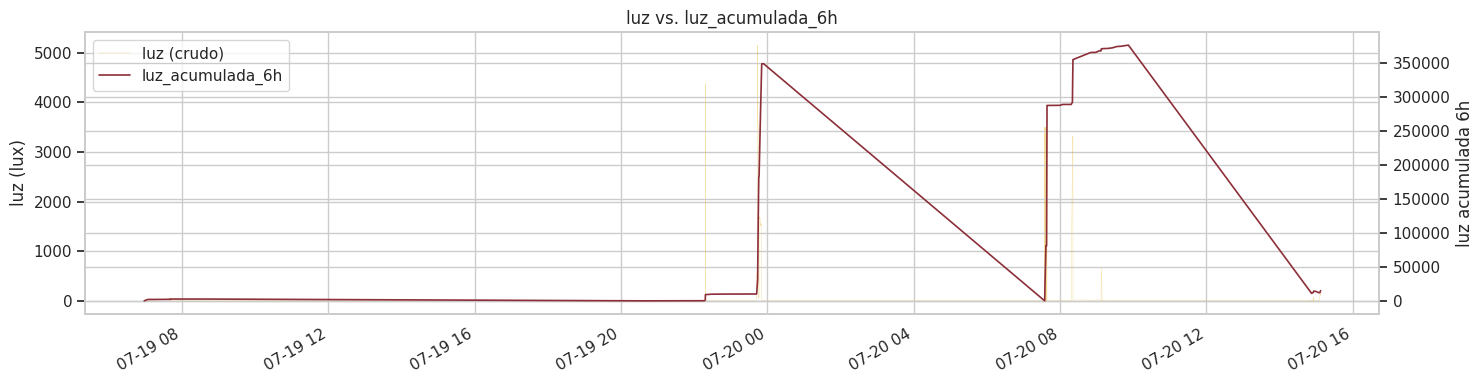

In [10]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(d["timestamp"], d["luz"], linewidth=0.3, alpha=0.4, label="luz (crudo)", color="#e0a800")
ax2 = ax.twinx()
ax2.plot(d["timestamp"], d["luz_acumulada_6h"], linewidth=1.2, color="#8c2f39", label="luz_acumulada_6h")
ax.set_ylabel("luz (lux)")
ax2.set_ylabel("luz acumulada 6h")
ax.set_title("luz vs. luz_acumulada_6h")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 4. Correlación de las features nuevas entre sí y con las etiquetas del motor de reglas

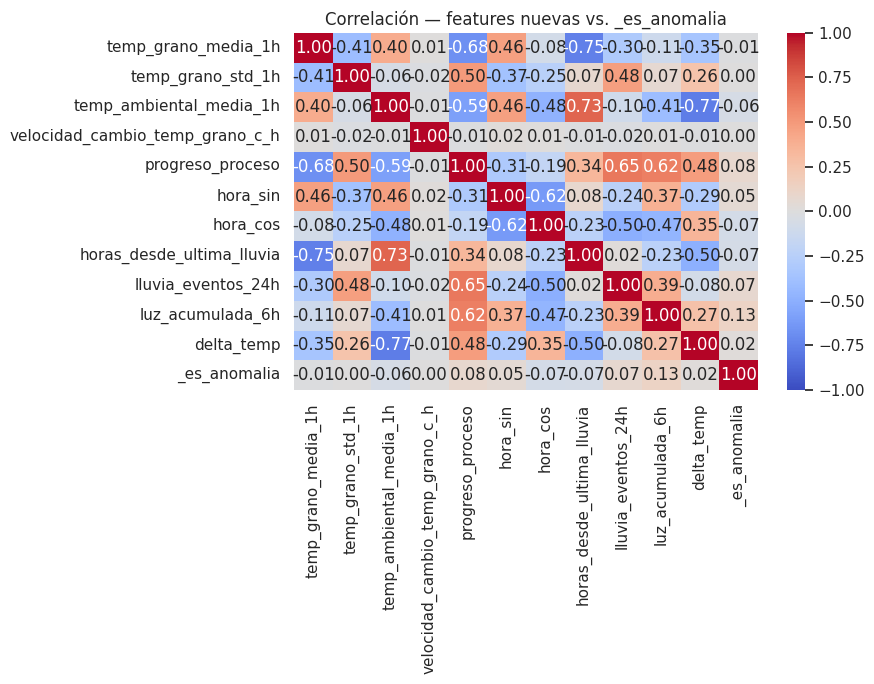

In [11]:
cols_correlacion = fe.COLUMNAS_NUEVAS + ["delta_temp", "_es_anomalia"]
corr_df = df_features[cols_correlacion].copy()
corr_df["_es_anomalia"] = corr_df["_es_anomalia"].astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación — features nuevas vs. _es_anomalia")
fig.tight_layout()
plt.show()


**Nota de honestidad estadística:** con un solo lote real de volumen (id_lote=12) y muy pocas
anomalías marcadas, esta correlación es más una prueba de que las fórmulas funcionan como se
espera que una conclusión predictiva definitiva — se vuelve más informativa según se acumulen más
lotes reales.

## 5. Verificación de nulos en las columnas nuevas

In [12]:
nulos = df_features[fe.COLUMNAS_NUEVAS].isna().sum()
print(nulos)
print()
print("Nota esperada: 'velocidad_cambio_temp_grano_c_h' y 'horas_desde_ultima_lluvia' pueden")
print("tener nulos en la PRIMERA lectura de cada lote (no hay 'anterior' contra qué comparar,")
print("o el lote nunca ha tenido lluvia sostenida todavía) — no es un error de cómputo.")


temp_grano_media_1h                   0
temp_grano_std_1h                     5
temp_ambiental_media_1h               0
velocidad_cambio_temp_grano_c_h       1
progreso_proceso                      0
hora_sin                              0
hora_cos                              0
horas_desde_ultima_lluvia          2133
lluvia_eventos_24h                    0
luz_acumulada_6h                      0
dtype: int64

Nota esperada: 'velocidad_cambio_temp_grano_c_h' y 'horas_desde_ultima_lluvia' pueden
tener nulos en la PRIMERA lectura de cada lote (no hay 'anterior' contra qué comparar,
o el lote nunca ha tenido lluvia sostenida todavía) — no es un error de cómputo.


## 6. Exportar dataset con features (listo para el paso 6: train/test split)

In [13]:
os.makedirs("../data/processed", exist_ok=True)
RUTA_FEATURES = "../data/processed/lecturas_reales_features.csv"
df_features.to_csv(RUTA_FEATURES, index=False)
print(f"Guardado: {RUTA_FEATURES}  ({len(df_features):,} filas, {len(df_features.columns)} columnas)")


Guardado: ../data/processed/lecturas_reales_features.csv  (7,458 filas, 31 columnas)


## 7. Conclusiones y siguiente paso

- Se agregaron 10 columnas derivadas sin modificar ninguna columna original del paso 4 — el
  dataset de features es un superconjunto del dataset limpio, así que sigue siendo compatible
  con cualquier código que ya use las columnas anteriores (p.ej. `NUMERIC_FEATURES` en
  `scripts/train_models.py`).
- Todas las ventanas móviles y diffs se calculan **agrupando por `id_lote`**, para no mezclar la
  serie de tiempo de un lote con la de otro — importante ahora que hay más de un lote en el
  dataset.
- Las features de lluvia acumulada (`horas_desde_ultima_lluvia`, `lluvia_eventos_24h`) usan
  `lluvia_sostenida` (paso 4), no la señal cruda con parpadeo — si en algún momento se corre este
  módulo sobre un CSV que no pasó por el paso 4, cae de vuelta a la cruda con un aviso explícito
  en consola (ver `ingenieria_caracteristicas.py`).

**Pendiente de decisión del equipo (no de este notebook):** `scripts/train_models.py` todavía
tiene su propia función `cargar_y_limpiar()` con una limpieza más simple (solo relleno por
mediana) y lee directo de `data/raw/lecturas_reales_entrenamiento.csv`, sin pasar por los pasos 4
y 5 documentados aquí. Antes de entrenar con las features nuevas, hay que decidir si
`train_models.py` se actualiza para leer `data/processed/lecturas_reales_features.csv` en vez de
recalcular su propia limpieza — así paso 4, 5 y 6/7 quedan alineados en una sola fuente de verdad,
igual que ya pasa con `app/services/rules.py`.

**Siguiente paso natural:** paso 6, separar entrenamiento/prueba con `GroupShuffleSplit` por
`id_lote` (ya implementado de forma parcial en `train_models.py`), y una vez resuelto el punto
anterior, reentrenar los 4 artefactos con este dataset enriquecido.
